In [1]:
import os
os.chdir("../")
cwd = os.getcwd()
print(cwd)

/home/ruchirich/Documents/repositories/toronto-open-data/toronto-island-park


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

from utils.download_data import download_data
import math

# Refresh data from Toront Open Data

In [3]:
# Datasets are called "packages". Each package can contain many "resources"
# To retrieve the metadata for this package and its resources, use the package name in this page's URL:
params = { "id": "toronto-island-ferry-ticket-counts"}
download_file = cwd+"/data/toronto-island-ferry-ticket-counts.csv"

download_data(params, download_file)

In [4]:
df = pd.read_csv(download_file, index_col='Timestamp', parse_dates=True, date_format="ISO8601", usecols=['Timestamp', 'Sales Count', 'Redemption Count'])
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 237331 entries, 2025-01-23 16:30:00 to 2015-05-01 13:30:00
Data columns (total 2 columns):
 #   Column            Non-Null Count   Dtype
---  ------            --------------   -----
 0   Redemption Count  237331 non-null  int64
 1   Sales Count       237331 non-null  int64
dtypes: int64(2)
memory usage: 5.4 MB


Daily aggregate is more informative than a sparse 15 minutes timeseries

In [5]:
og_df = df.copy()
df = df.resample(rule='W').sum()
df.columns = ["redemption", "sales"] # concise column names
df.index.name = 'date' # rename for ease of use
df.head()

,redemption,sales
date,,
2015-05-03,1,4
2015-05-10,13606,17241
2015-05-17,18006,25334
2015-05-24,30138,36152
2015-05-31,15919,18554


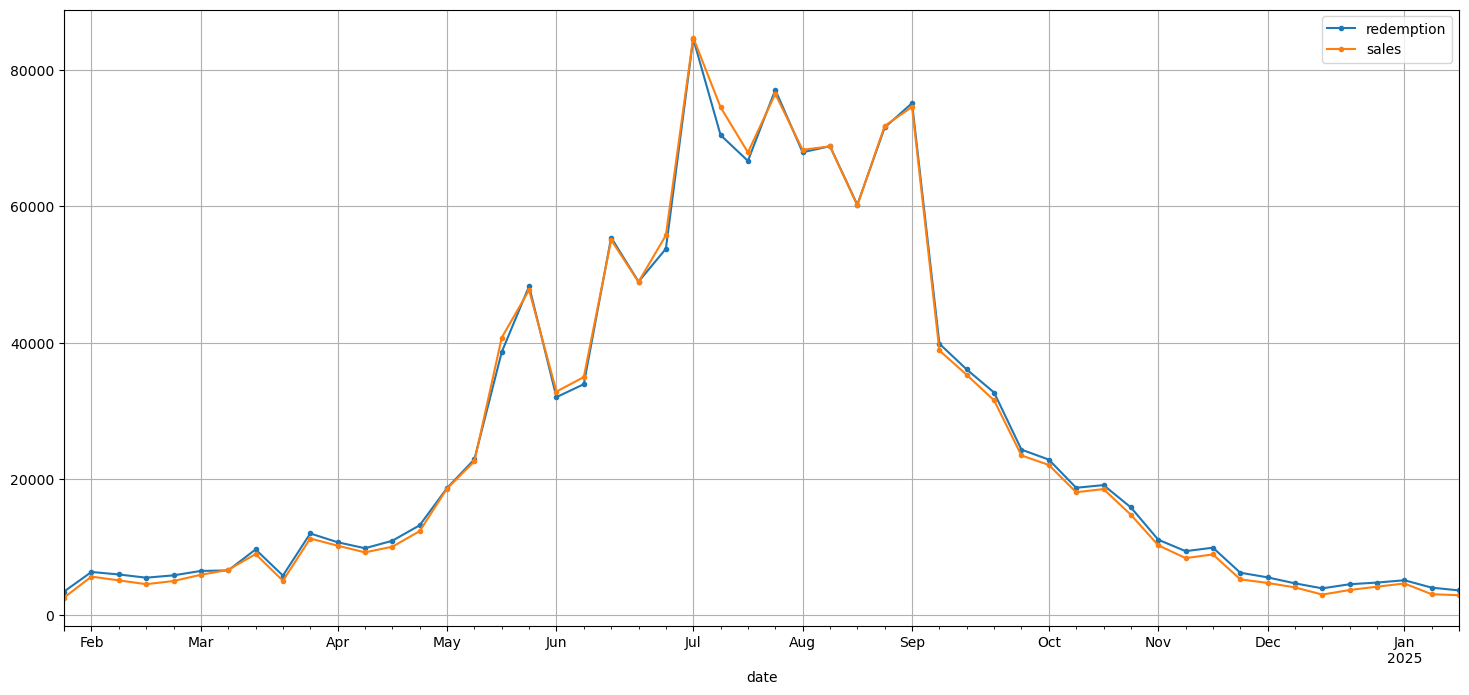

In [6]:
start = pd.Timestamp.now().normalize() - pd.Timedelta(days=365)
end = pd.Timestamp.now().normalize()
df[start:end].plot(grid=True, figsize=(18, 8), marker=".")
plt.show()

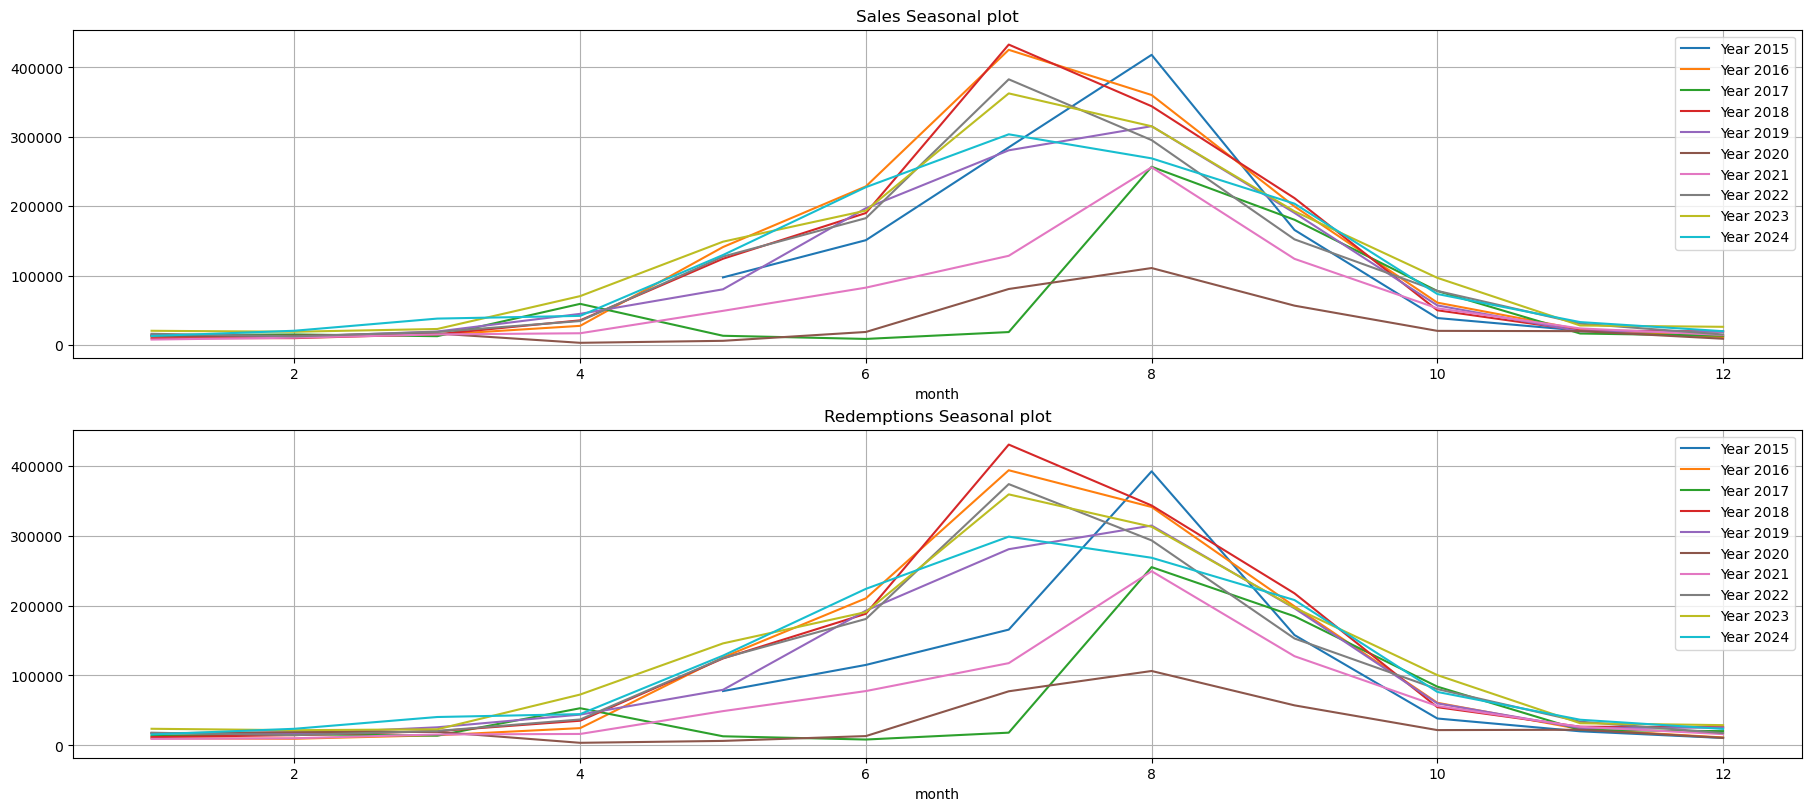

In [7]:
monthly = df.groupby([df.index.year, df.index.month]).sum() # in other cases, USE resample instead for ts data. Here groups are helpful to plot seasonal data
monthly.index.names = ['year', 'month']
year_list = list(df.index.year.unique())
year_list.remove(2025)
fig, axs = plt.subplots(2, 1, constrained_layout=True)
for year in year_list:    
    monthly.loc[year,'sales'].plot.line(
        ax=axs[0],
        title='Sales Seasonal plot',
        label= f"Year {year}",
        figsize=(18, 8),
        legend=True,
        grid=True
    )
    monthly.loc[year,'redemption'].plot.line(
        ax=axs[1],
        title='Redemptions Seasonal plot',
        label= f"Year {year}",
        figsize=(18, 8),
        legend=True,
        grid=True
    )

# 1Y Naive forecast

Simply use the past data as the forecast

The data has monthly seasonality, so differencing by 365 days lag

In [8]:
# zooming in to last 3 years for readability of plot
start = pd.Timestamp.now().normalize() - pd.Timedelta(days=365*2)
end = pd.Timestamp.now().normalize() - pd.Timedelta(days=365)

In [9]:
print(start)
print(end)

2023-01-24 00:00:00
2024-01-24 00:00:00


In [10]:
diff_365 = df.diff(365).loc[start:end]
diff_365.head()

,redemption,sales
date,,
2023-01-29,2075.0,-153.0
2023-02-05,1721.0,968.0
2023-02-12,3881.0,3214.0
2023-02-19,3499.0,-595.0
2023-02-26,3135.0,2663.0


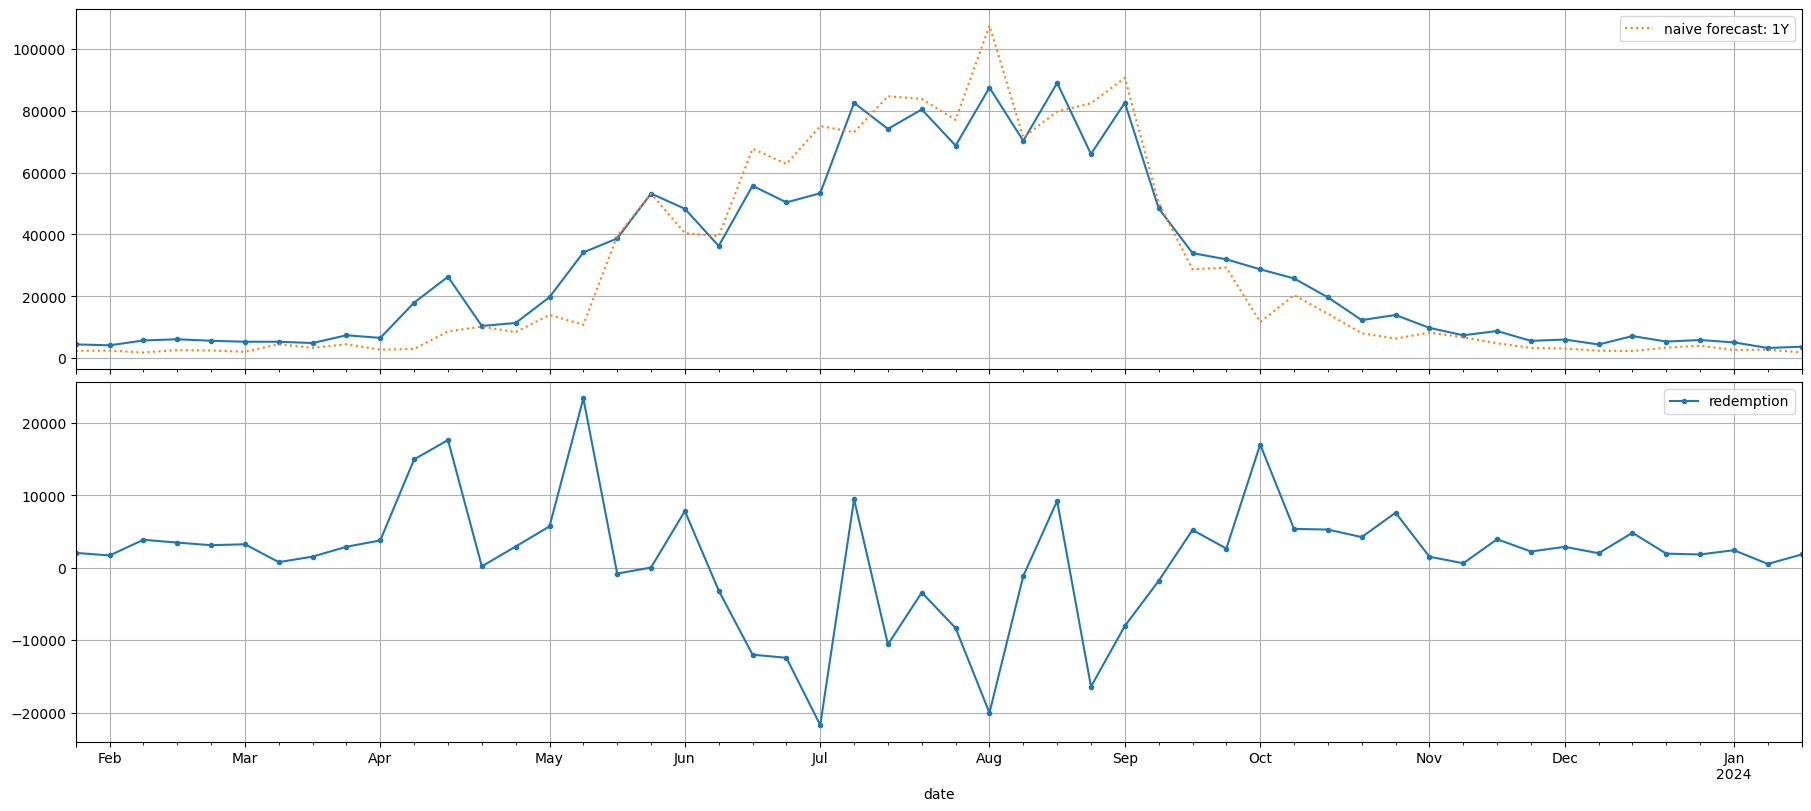

In [11]:
fig, axs = plt.subplots(2, 1, sharex=True, constrained_layout=True, figsize=(18, 8))
df.loc[start:end,'redemption'].plot(
    ax=axs[0],
    grid=True,
    legend=False,
    marker="."
    )

df.shift(365).loc[start:end,'redemption'].plot(
    ax=axs[0],
    grid=True,
    legend=True,
    label="naive forecast: 1Y",
    linestyle=":"
)

diff_365.loc[start:end,'redemption'].plot(
    ax=axs[1],
    grid=True,
    legend=True,
    marker="."
)

plt.show()

Mean Absolute Error (MAE):

In [12]:
diff_365.abs().mean()

redemption    6005.173077
sales         6709.788462
dtype: float64

In [13]:
targets = df.loc[start:end]
targets.head()

,redemption,sales
date,,
2023-01-29,4466,3521
2023-02-05,4166,3702
2023-02-12,5730,4929
2023-02-19,6122,5427
2023-02-26,5640,4873


Errors in the forecast (pct of original values for year 2024-2025)

Mean absolute Percentage error (MAPE)

In [14]:
(diff_365 / targets).abs().mean() * 100

redemption    31.779172
sales         29.510085
dtype: float64

accuracy

In [15]:
((targets - diff_365) / targets).abs().mean() * 100

redemption    75.558149
sales         83.344275
dtype: float64

# Annual trend

12 mo. MA

In [23]:
period = slice("2015", "2023")

In [31]:
df_monthly = og_df.resample('ME').mean()
df_weekly = og_df.resample('WE').mean()

In [32]:
rolling_avg_12_month = df_monthly[period].rolling(window=12).mean()
rolling_avg_4_week = df[period].rolling(window=4).mean()

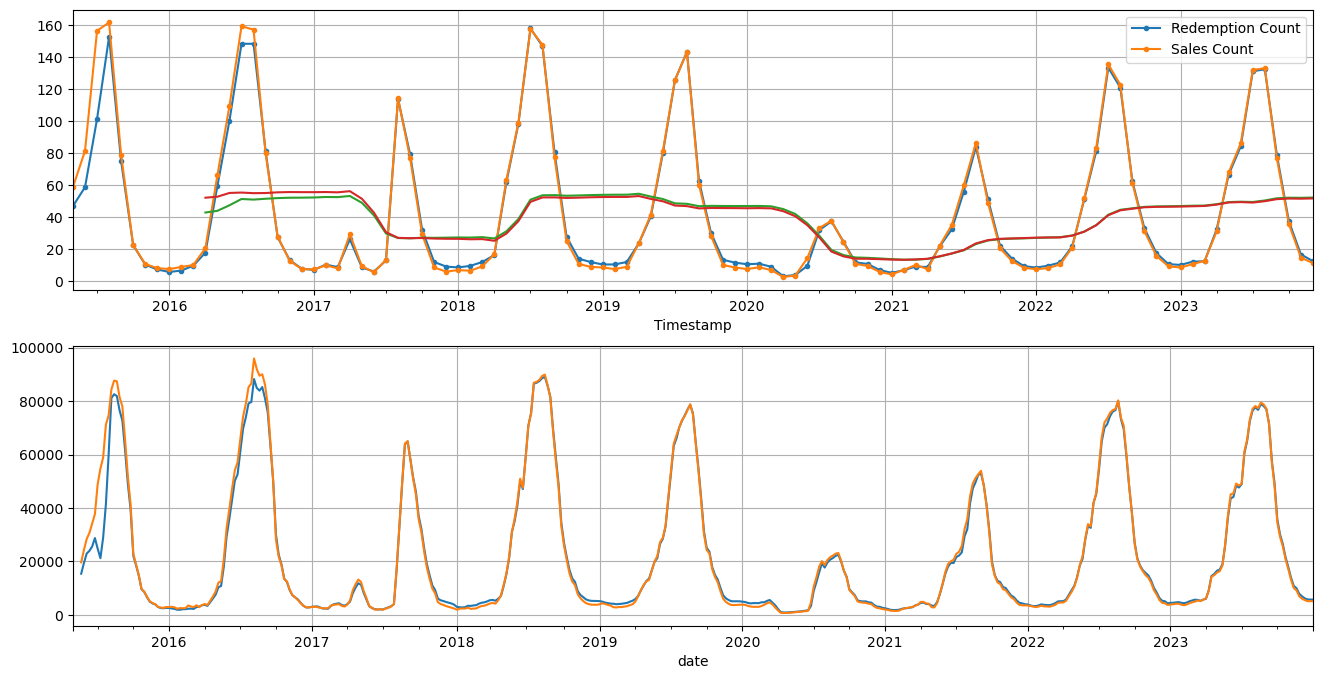

In [36]:
fig, ax = plt.subplots(2, 1, figsize=(16, 8))
df_monthly[period].plot.line(ax=ax[0], marker=".")
rolling_avg_12_month.plot(ax=ax[0], grid=True, legend=False)
rolling_avg_4_week.plot(ax=ax[1], grid=True, legend=False)
plt.show()